In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
portfolio = pd.read_csv("portfolio.csv")
trades = pd.read_csv("trades.csv")
kospi = pd.read_excel("kospi.xlsx").rename(columns={"Ticker":"ticker"})[1:][["Name","ticker"]]
kospi["ticker"] = [int(x) for x in kospi["ticker"]]
trades = trades.merge(kospi,on="ticker",how="left")
trades["count"] = 1

In [3]:
kospi

,Name,ticker
1,SamsungElec,5930
2,SK hynix,660
3,LG Energy Solution,373220
4,SAMSUNG BIOLOGICS,207940
5,Celltrion,68270
...,...,...
754,Charm Engineering,9310
755,Jayjun Cosmetic,25620
756,KumhoElec,1210
757,IljeongInd,8500


In [4]:
portfolio["rolling_return"] = portfolio["return"].rolling(10).mean()

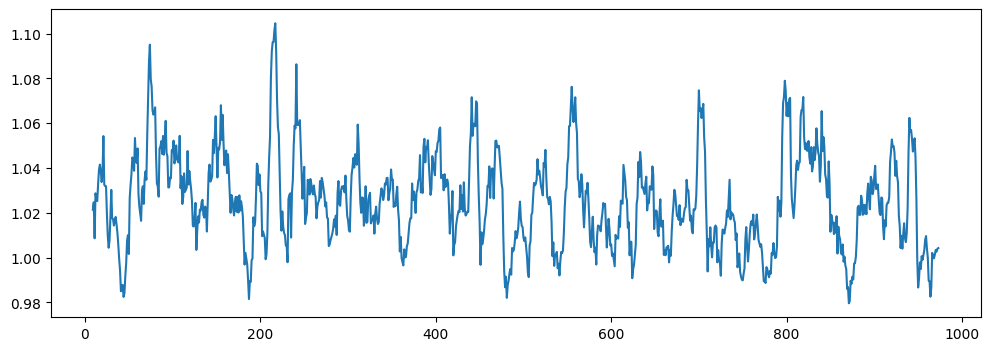

In [5]:
fig, ax = plt.subplots()
ax.plot(portfolio["rolling_return"].values)
fig.set_size_inches(12, 4) 
plt.show()

In [6]:
ticker_view = trades.groupby(["ticker","Name"]).aggregate({"return":"mean","count":"sum"}).sort_values("count",ascending=False).reset_index().head(10)
ticker_view["return"] = ticker_view["return"] + 1
ticker_view["total_return"] = ticker_view["return"] ** ticker_view["count"]
ticker_view.sort_values("count",ascending=False).head(20)

,ticker,Name,return,count,total_return
0,1260,NamkwangEng&Const,1.006401,120,2.150377
1,4770,SunnyElec,1.009307,85,2.197837
2,11000,GENEONE,1.012158,79,2.597825
3,71970,STX Heavy Industries,1.003872,77,1.346563
4,25620,Jayjun Cosmetic,1.007937,75,1.809311
5,9320,DAEWOOELECCOMPONENTS,1.009549,72,1.982248
6,1470,SambuConst,1.005010,68,1.404675
7,10600,WELLBIOTEC,1.006318,56,1.422865
8,2780,ChinhungInt,1.000282,53,1.015050
9,9190,DaiyangMtl,1.002740,50,1.146590


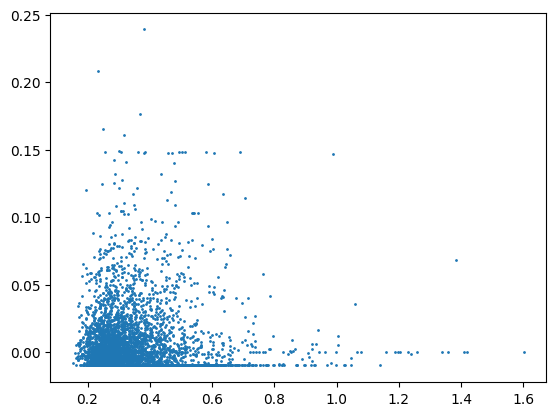

In [7]:
plt.scatter(trades["coefficient_of_variance"],trades["return"],s=1)
plt.show()

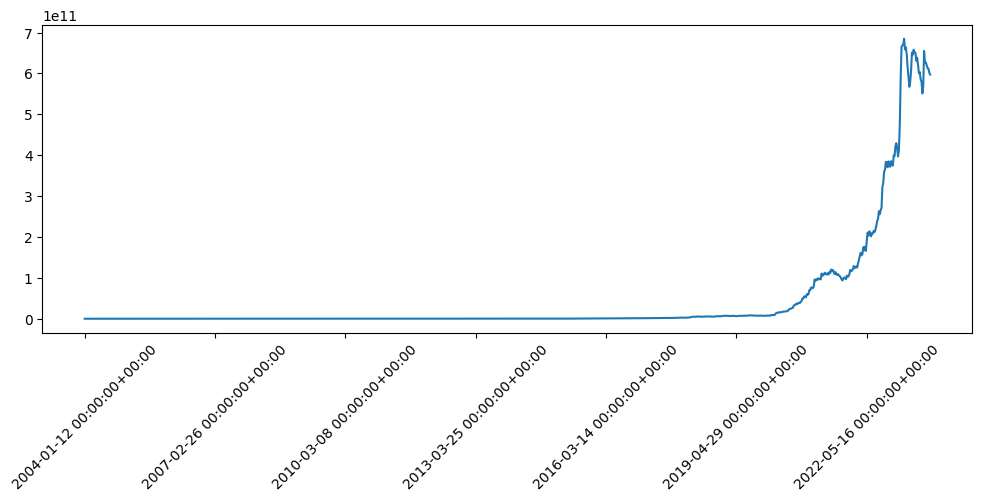

In [8]:
import matplotlib.pyplot as plt
import mplcursors
from matplotlib.ticker import MaxNLocator

# Assuming portfolio is a Pandas DataFrame with a "date" column and a "cumulative_return" column

fig, ax = plt.subplots()
line, = ax.plot(portfolio["date"], portfolio["cumulative_return"].values)

# Set the figure size
fig.set_size_inches(12, 4)

# Use MaxNLocator to automatically choose a suitable number of ticks on the x-axis
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))  # You can adjust the number of ticks as needed

# Rotate the x-axis labels for better visibility if necessary
plt.xticks(rotation=45)

# Add hover labels using mplcursors
cursor = mplcursors.cursor(hover=True)
cursor.connect("add", lambda sel: sel.annotation.set_text(
    f'Point of Interest: {sel.target[1]:.2f}'))

plt.show()
